In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

In [57]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.tail()

Training data shape: (123509, 626)
Training date range: 2018-10-16 to 2023-04-09
Validation data shape: (26401, 621)
Validation date range: 2023-10-24 to 2024-04-14
Test data shape: (26306, 621)
Test date range: 2024-10-22 to 2025-04-13


,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,percentagePointsFreeThrow_ROLLING_AVG_5,PTS_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FTM_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,PACE_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,POSS_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,percentagePointsPaint_ROLLING_AVG_7,percentagePointsMidrange2pt_ROLLING_AVG_7,percentagePoints3pt_ROLLING_AVG_7,percentagePointsFreeThrow_ROLLING_AVG_7,PTS_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,percentagePointsFreeThrow_ROLLING_AVG_10,PTS_ROLLING_AVG_15,FGA_ROLLING_AVG_15,FG3A_ROLLING_AVG_15,FTM_ROLLING_AVG_15,FG_PCT_ROLLING_AVG_15,TS_PCT_ROLLING_AVG_15,USG_PCT_ROLLING_AVG_15,MIN_ROLLING_AVG_15,PACE_ROLLING_AVG_15,TCHS_ROLLING_AVG_15,POSS_ROLLING_AVG_15,EFG_PCT_ROLLING_AVG_15,percentagePointsPaint_ROLLING_AVG_15,percentagePointsMidrange2pt_ROLLING_AVG_15,percentagePoints3pt_ROLLING_AVG_15,percentagePointsFreeThrow_ROLLING_AVG_15,PTS_ROLLING_AVG_25,FGA_ROLLING_AVG_25,FG3A_ROLLING_AVG_25,FTM_ROLLING_AVG_25,FG_PCT_ROLLING_AVG_25,TS_PCT_ROLLING_AVG_25,USG_PCT_ROLLING_AVG_25,MIN_ROLLING_AVG_25,PACE_ROLLING_AVG_25,TCHS_ROL

In [52]:
newFeatures = train_df.columns[train_df.columns.tolist().index('STARTING'):].tolist()

In [61]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

def select_features_xgb_importance(
    X,
    y,
    top_n=40,
    n_runs=5,
    include_context=True,
    validate_permutation=False
):
    feature_scores = np.zeros(X.shape[1])

    # Run multiple XGBoost fits to stabilize importance
    for seed in range(n_runs):
        xgb = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42 + seed,
            verbosity=0
        )
        xgb.fit(X, y)
        feature_scores += xgb.feature_importances_

    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': feature_scores / n_runs
    }).sort_values('importance', ascending=False)

    top_features = importance_df.head(top_n)['feature'].tolist()

    # Add context features that improve stability and interpretability
    if include_context:
        context_features = [

            'HOME_GAME', 'BACK_TO_BACK', 'PLAYER_DAYS_REST', 
            # 'GUARD', 'FORWARD', 'CENTER',
            'TEAM_PACE_AVG_TO_DATE', 'TEAM_OFF_RATING_AVG_TO_DATE',
            'OPP_DEF_RATING_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE', 'OPP_TOV_AVG_TO_DATE',
            'OPP_FORWARD_DEF_RATING', 'OPP_CENTER_DEF_RATING', 'OPP_GUARD_DEF_RATING',
            'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_10', 'MIN_LAG_1', 
            'MIN_AVG_TO_DATE', 'MIN_VOLATILITY_10_TO_DATE', 'MIN_VOLATILITY_5_TO_DATE'
            'MIN_STD_LAST_5'
        ]
        for f in context_features:
            if f in X.columns and f not in top_features:
                top_features.append(f)

    # Optional: Permutation importance validation
    if validate_permutation:
        print("Validating with permutation importance...")
        model = XGBRegressor(n_estimators=300, random_state=42, verbosity=0)
        model.fit(X[top_features], y)
        perm = permutation_importance(model, X[top_features], y, n_repeats=5, random_state=42)
        perm_df = pd.DataFrame({
            'feature': top_features,
            'perm_importance': perm.importances_mean
        }).sort_values('perm_importance', ascending=False)

        # Filter out weak features
        perm_df = perm_df[perm_df['perm_importance'] > 0]
        top_features = perm_df['feature'].tolist()

    print(f"Selected {len(top_features)} total features")
    print("Top 10 most important:")
    for i, f in enumerate(top_features[:10]):
        print(f"{i+1}. {f}")

    return X[top_features], top_features


In [62]:
selected_features, top_features = select_features_xgb_importance(
    train_df[newFeatures],
    train_df['PTS'],
    top_n=50,                 # increase if you want more coverage
    n_runs=5,                 # stabilizes importance ranking
    include_context=True,     # adds game context
    validate_permutation=False # prunes noise
)

Selected 61 total features
Top 10 most important:
1. PTS_ROLLING_AVG_40
2. PTS_ROLLING_AVG_15
3. EXPECTED_USAGE_MIN
4. PTS_ROLLING_AVG_25
5. FGA_ROLLING_AVG_10
6. PTS_ROLLING_AVG_10
7. FGA_ROLLING_AVG_7
8. PTS_PER_MIN_X_POSS
9. USG_X_POSS
10. PTS_ROLLING_AVG_7


# XGBOOST MODEL

In [63]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,  
    tune_hyperparams=False,
    tune_iters=200
)
test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "PTS", used_cats)

print("=" * 50)
print("MODEL TRAINING COMPLETE!")
print(f"VAL RMSE: {val_metrics['RMSE']:.2f}")
print(f"VAL MAE: {val_metrics['MAE']:.2f}")
print(f"VAL R²: {val_metrics['R2']:.2f}")
print("-" * 50)
print(f"TEST RMSE: {test_metrics['RMSE']:.2f}")
print(f"TEST MAE: {test_metrics['MAE']:.2f}")
print(f"TEST R²: {test_metrics['R2']:.2f}")

print("=" * 50)

if val_metrics['RMSE'] < 5.5:
    print("EXCELLENT MODEL - Ready for betting!")
elif val_metrics['RMSE'] < 6.0:
    print("GOOD MODEL - Solid for betting!")
else:
    print("Model needs improvement")


MODEL TRAINING COMPLETE!
VAL RMSE: 5.63
VAL MAE: 4.31
VAL R²: 0.61
--------------------------------------------------
TEST RMSE: 5.80
TEST MAE: 4.45
TEST R²: 0.57
GOOD MODEL - Solid for betting!


Try LightGBM or CatBoost with monotonic constraints on usage and minutes.

Use quantile loss for robustness to outliers.

Use per-player normalization for rolling stats (e.g., z-score per player).

In [64]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
           TOP_FEATURES  TOP_IMPORTANCE                BOTTOM_FEATURES  BOTTOM_IMPORTANCE
     PTS_ROLLING_AVG_15        0.241915         TEAM_AST_ROLLING_AVG_5           0.002672
     PTS_ROLLING_AVG_40        0.159391  TEAM_DEF_RATING_ROLLING_AVG_3           0.002612
     PTS_ROLLING_AVG_25        0.121545         USG_PCT_ROLLING_AVG_25           0.002580
     EXPECTED_USAGE_MIN        0.120719         USG_PCT_ROLLING_AVG_10           0.002569
               STARTING        0.048885     PTS_PER_MIN_ROLLING_AVG_40           0.002527
     PTS_ROLLING_AVG_10        0.044638         OPP_FORWARD_DEF_RATING           0.002513
      FGA_ROLLING_AVG_7        0.027600         USG_PCT_ROLLING_AVG_15           0.002503
       PTS_WITHOUT_STAR        0.015809        ROLLING_PTS5_X_TEAM_OFF           0.002498
      FGA_ROLLING_AVG_5        0.015323   PTS_PER_MIN_X_OPP_DEF_RATING           0.002498
    PLAYER_IS_TEAM_STAR        0.015098          USG_PCT

In [65]:
joblib.dump(xgbModel, 'Models/xgbPTSModel25.pkl')
joblib.dump(top_features, 'Models/topPTSfeatures25.pkl')

['Models/topPTSfeatures25.pkl']

In [60]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN
0,0,27.304270,27.304270,Anthony Davis,LAL @ GSW,115,113.0,1,7.20
1,5,30.579172,25.579172,Tyrese Maxey,PHI vs. GSW,126,119.0,1,39.82
2,0,24.929565,24.929565,Jaren Jackson Jr.,MEM vs. ATL,130,132.0,1,1.65
3,9,30.710272,21.710272,Anthony Edwards,MIN vs. BKN,117,91.0,1,30.52
4,4,25.520048,21.520048,Anthony Davis,LAL @ PHI,104,118.0,1,9.83
5,0,21.305910,21.305910,Alperen Sengun,HOU vs. TOR,94,87.0,1,3.27
6,2,22.924915,20.924915,DeMar DeRozan,SAC vs. PHX,127,104.0,1,17.43
7,5,25.569839,20.569839,Brandon Ingram,NOP vs. OKC,109,119.0,1,18.90
8,12,32.555714,20.555714,LaMelo Ball,CHA @ BKN,115,116.0,1,23.95
9,7,26.391987,19.391987,Franz Wagner,ORL vs. IND,119,115.0,1,10.88


C:\Users\alexg\AppData\Local\Temp\ipykernel_7044\1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_7044\1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


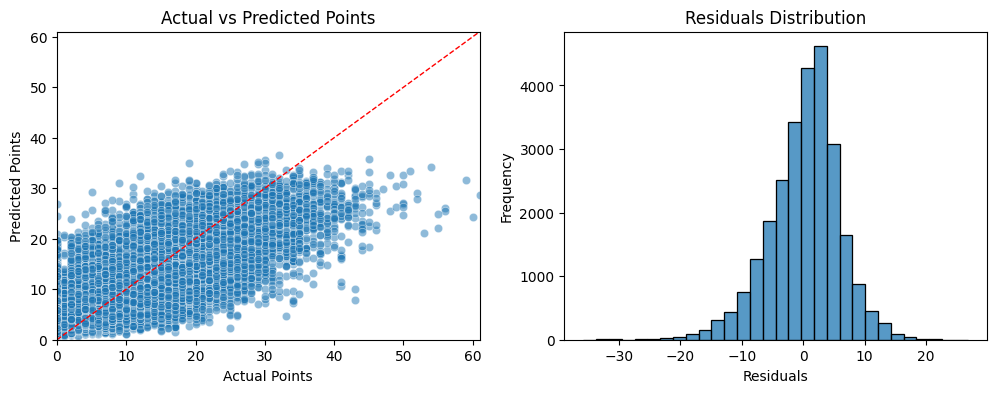

In [66]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

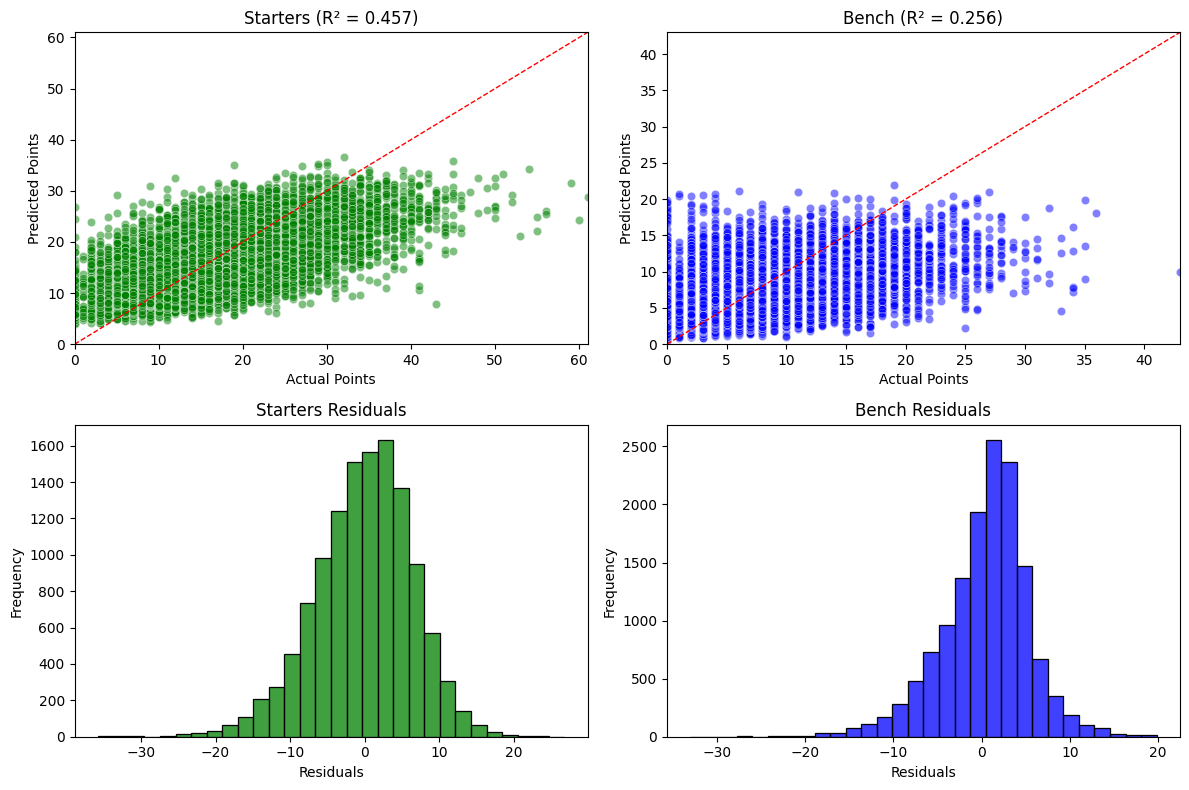

In [67]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]
starters_r2 = r2_score(starters['actual'], starters['predicted'])
bench_r2 = r2_score(bench['actual'], bench['predicted'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


In [ ]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]
star_r2 = r2_score(starPlayers['actual'], starPlayers['predicted'])
nonStar_r2 = r2_score(nonStarPlayers['actual'], nonStarPlayers['predicted'])

starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]
starsIn_r2 = r2_score(starsIn['actual'], starsIn['predicted'])
starsOut_r2 = r2_score(starsOut['actual'], starsOut['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Team Star Players
sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Team Star Players (R² = {star_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Non-Star Players
sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Non-Star Players (R² = {nonStar_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Star Players In
sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'Star Players In (R² = {starsIn_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Star Players Out
sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Star Players Out (R² = {starsOut_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('Star Players In Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Star Players Out Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

KeyError: 'PLAYER_IS_TEAM_STAR'

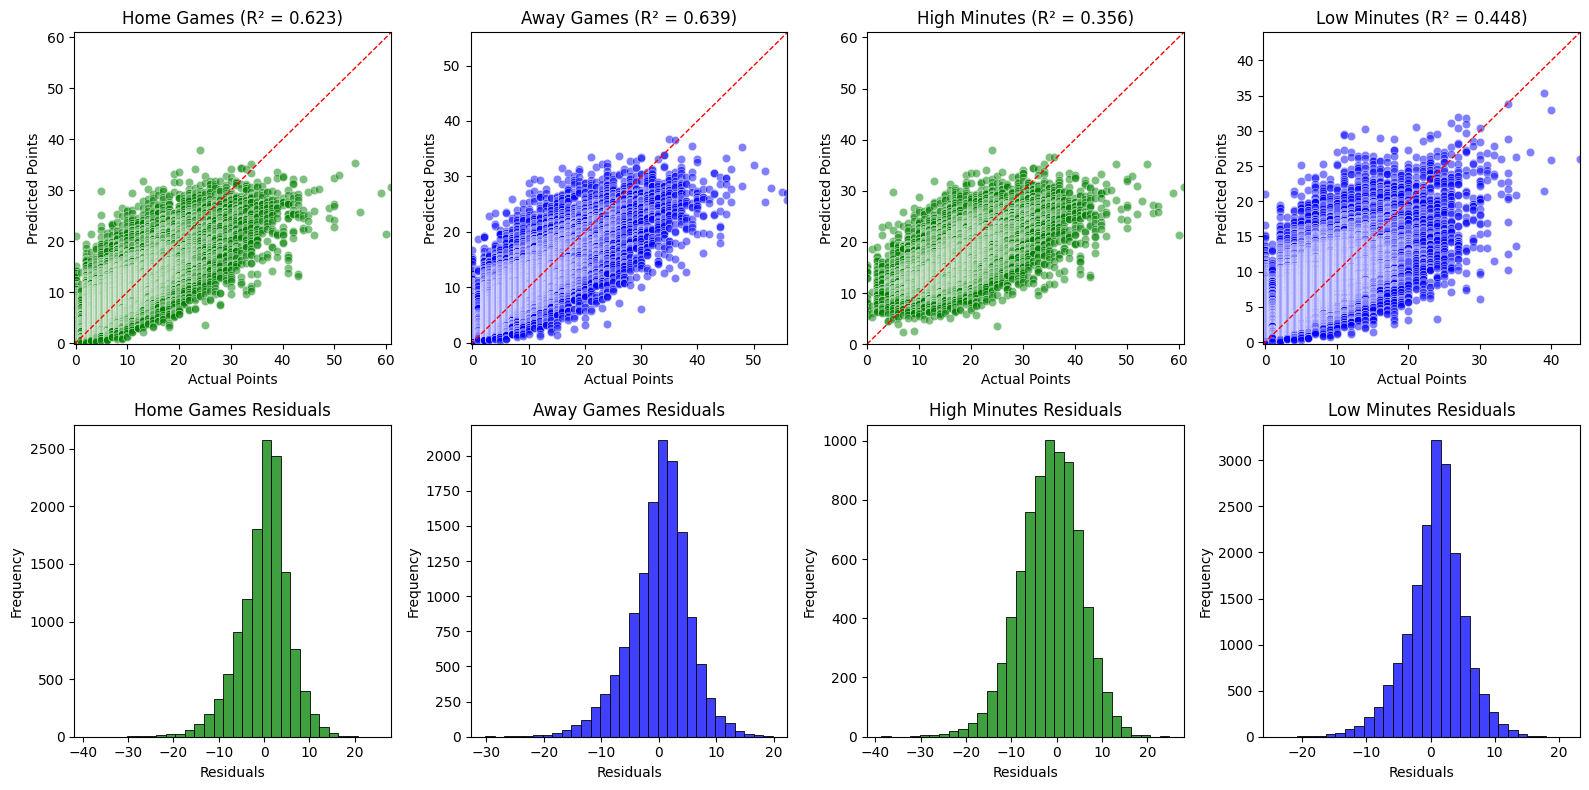

In [ ]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]
homeGames_r2 = r2_score(homeGames['actual'], homeGames['predicted'])
awayGames_r2 = r2_score(awayGames['actual'], awayGames['predicted'])

highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]
highMins_r2 = r2_score(highMins['actual'], highMins['predicted'])
lowMins_r2 = r2_score(lowMins['actual'], lowMins['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Home Games
sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Home Games (R² = {homeGames_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Away Games
sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Away Games (R² = {awayGames_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# High Minutes
sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'High Minutes (R² = {highMins_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Low Minutes
sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Low Minutes (R² = {lowMins_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('High Minutes Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Low Minutes Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()